# Training CGNet in Antarctic Region ONLY WITH PSL

Purpose:
--------
The purpose of this notebook is to train CGnet for machine learning detection of atmospheric rivers and tropical cyclones.\
See ClimateNet repo here: https://github.com/andregraubner/ClimateNet

Note:
-----
In order to run this notebook, users should request 1 node, 2 cpu, 92GB mem, 2 V100 GPU

Authors/Contributors:
---------------------
* Teagan King
* John Truesdale
* Katie Dagon

## Import libraries

In [2]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/glade/work/tking/cgnet/ClimateNet")  # append path to ClimateNet repo
from climatenet.utils.data import ClimateDatasetLabeled, ClimateDataset
from climatenet.models import CGNet
from climatenet.utils.utils import Config
from climatenet.track_events import track_events
from climatenet.analyze_events import analyze_events
from climatenet.visualize_events import visualize_events
from climatenet.analyze_polar_events import just_polar_plots_analyze_events

from IPython.display import Image
from os import path

import torch
import xarray as xr
import dask

## Config file
Use `get_averages_and_standard_devs.ipynb` to calculate means/stds for given training dataset.

In [3]:
cd /glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL

/glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL


In [4]:
config = Config('config.json')

In [5]:
config.train_batch_size

4

## Confirm GPU resources

In [6]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
2


## Instantiate CGNet model given config file

In [8]:
%%time
cgnet = CGNet(config)

CPU times: user 1.53 s, sys: 903 ms, total: 2.43 s
Wall time: 6.42 s


In [9]:
cgnet.optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    eps: 1e-08
    lr: 0.001
    weight_decay: 0
)

## Set train, test data

In [8]:
train_path = '/glade/work/tking/cgnet/QA_xml/all_antarctic_converted_masks/split_files'

train = ClimateDatasetLabeled(path.join(train_path+'/train'), config)
test = ClimateDatasetLabeled(path.join(train_path+'/test'), config)

In [9]:
train.fields

{'psl': {'mean': 101001.370879, 'std': 1387.300643}}

In [10]:
train.length

622

In [11]:
config.epochs

20

## Train model

Memory use holding at ~14GB during training\
Each epoch takes ~1 min to run

NOTE: This was failing when pred and train batch size were set to 16 in config; it runs with both set to 4.

In [12]:
cgnet.train(train)
# IOU mean should be around 0.75 after all epochs?

  0%|          | 0/156 [00:00<?, ?it/s]

Epoch 1:


  0%|          | 0/156 [00:00<?, ?it/s]

Epoch stats:
[[7.52766448e+08 2.81182000e+07 0.00000000e+00]
 [4.05878270e+07 3.98621300e+06 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.91636235 0.05483684 1.        ] , mean:  0.6570663980273506
Epoch 2:


  0%|          | 0/156 [00:00<?, ?it/s]

...

Epoch stats:
[[7.61108537e+08 1.97761110e+07 0.00000000e+00]
 [2.23690710e+07 2.22049690e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94753192 0.34506475 1.        ] , mean:  0.7641988905368838
Epoch 19:


  0%|          | 0/156 [00:00<?, ?it/s]

Epoch stats:
[[7.60661516e+08 2.02231320e+07 0.00000000e+00]
 [2.18988820e+07 2.26751580e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94753005 0.34994055 1.        ] , mean:  0.7658235323281918
Epoch 20:


Loss: 0.6058878898620605: 100%|██████████| 156/156 [01:50<00:00,  1.41it/s]

Epoch stats:
[[7.60939436e+08 1.99452120e+07 0.00000000e+00]
 [2.12387480e+07 2.33352920e+07 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00]]
IOUs:  [0.94865633 0.36167952 1.        ] , mean:  0.7701119490747002


In [19]:
# LOSS AND IOU FROM ABOVE, 1-5 included first row, 6-10 second row, etc

Loss_tmq_20_epochs = [0.6291141510009766, 0.621066153049469, 0.6221991777420044, 0.6157857179641724, 0.6245676279067993,
                      0.6237830519676208, 0.6285338997840881, 0.6180511713027954, 0.6197284460067749, 0.6090837717056274,
                      0.6131657958030701, .6178664565086365, 0.625179648399353, 0.6142792701721191, 0.6122597455978394,
                      0.6225176453590393, 0.6099214553833008, 0.6031895875930786, 0.6128816604614258, 0.6058878898620605]

iou_tmq_20_epochs = [[0.91636235, 0.05483684, 1], [0.94219004, 0.09829133, 1], [0.9409693, 0.13268809, 1], [0.94138173, 0.15745059, 1],
                     [0.94087212, 0.17582918, 1], [0.9405247,  0.19942743, 1], [0.94185111, 0.21718444, 1], [0.94153419, 0.23060161, 1],
                     [0.94161043, 0.24053625, 1], [0.94210698, 0.2529239, 1], [0.94183809, 0.26359583, 1], [0.94306491, 0.27738356, 1],
                     [0.94335689, 0.2874258,  1], [0.94383918, 0.29672378, 1],[0.94558926, 0.31285618, 1], [0.94556683, 0.32446827, 1],
                     [0.94710871, 0.33466591, 1], [0.94753192, 0.34506475, 1], [0.94753005, 0.34994055, 1], [0.94865633, 0.36167952, 1]]





                     

In [20]:
epoch_range = np.arange(1, config.epochs+1)

Text(0.5, 1.0, 'CGNet Training History')

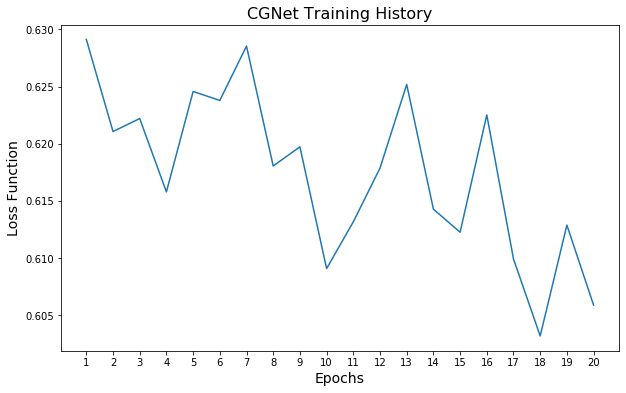

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(epoch_range, Loss_tmq_20_epochs)
plt.ylabel('Loss Function', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range)
plt.title('CGNet Training History', fontsize=16)

In [24]:
iou_mean = np.mean(iou_tmq_20_epochs, axis=1)
iou_mean

array([0.6570664 , 0.68016046, 0.69121913, 0.69961077, 0.7055671 ,
       0.71331738, 0.71967852, 0.72404527, 0.72738223, 0.73167696,
       0.73514464, 0.74014949, 0.74359423, 0.74685432, 0.75281515,
       0.75667837, 0.76059154, 0.76419889, 0.76582353, 0.77011195])

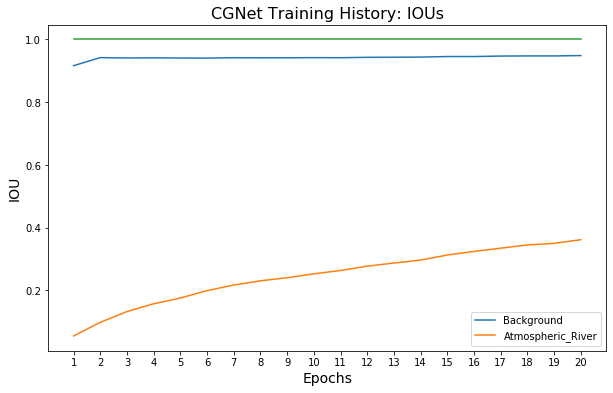

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(epoch_range, iou_tmq_20_epochs)
plt.ylabel('IOU', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range);
plt.title('CGNet Training History: IOUs', fontsize=16)
plt.legend(config.labels);  #+['Mean']);

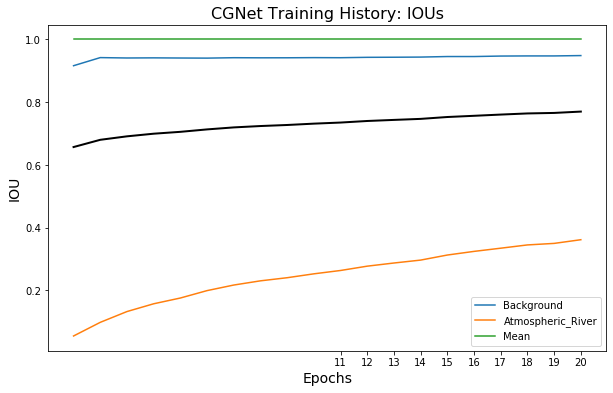

In [26]:
plt.figure(figsize=(10,6))
plt.plot(epoch_range, iou_tmq_20_epochs)
plt.plot(epoch_range, iou_mean, color='k', linewidth=2)
plt.ylabel('IOU', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range[10:]);
plt.title('CGNet Training History: IOUs', fontsize=16)
plt.legend(config.labels+['Mean'])

Text(0.5, 1.0, 'CGNet Training History: Mean IOU')

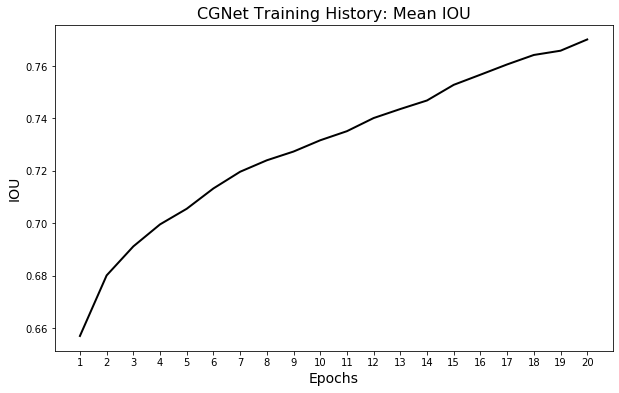

In [27]:
plt.figure(figsize=(10,6))
plt.plot(epoch_range, iou_mean, color='k', linewidth=2)
plt.ylabel('IOU', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range);
plt.title('CGNet Training History: Mean IOU', fontsize=16)

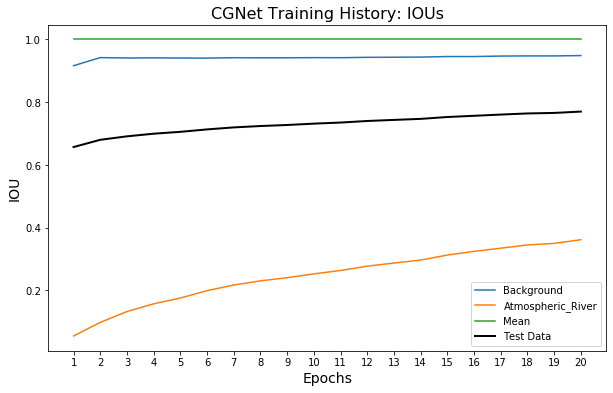

In [28]:
plt.figure(figsize=(10,6))
plt.plot(epoch_range, iou_tmq_20_epochs)
plt.plot(epoch_range, iou_mean, color='k', linewidth=2)
plt.ylabel('IOU', fontsize=14)
plt.xlabel('Epochs', fontsize=14)
plt.xticks(epoch_range);
plt.title('CGNet Training History: IOUs', fontsize=16)
plt.legend(config.labels+['Mean', 'Test Data'])

## Save out model

In [13]:
cgnet.save_model('/glade/work/tking/cgnet/ML-extremes/trained_models/trained_cgnet.092025_PSL')

## Load in previously trained model

In [10]:
cgnet.load_model('/glade/work/tking/cgnet/ML-extremes/trained_models/trained_cgnet.092025_PSL')

## Predict on test data
Need to reload test data as `ClimateDataset` in order to use `.predict`

In [53]:
test_path = train_path + "/test"
test_data = ClimateDataset(test_path, config)

In [59]:
%%time
test_masks = cgnet.predict(test_data)

 49%|████▊     | 19/39 [00:18<00:19,  1.03it/s]


RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

## Set inference data

In [ ]:
cd /glade/work/tking/cgnet/ML-extremes/trained_models/config_102025_PSL_INFERENCE/
# Need to set this up for inference data means/std!

In [ ]:
config = Config('config.json')

In [ ]:
config.description

In [ ]:
config.train_batch_size

In [11]:
inference_path = '/glade/campaign/cgd/ccr/tking/cgnet/underlying_processed_training_data/sh_polar/psl/split_xy/2000/'
inference = ClimateDataset(inference_path, config)  # could test different config with std/means for inference data

In [12]:
inference.fields

{'psl': {'mean': 101001.370879, 'std': 1387.300643}}

In [13]:
inference.length

2919

## Inference mode
This is now done more systematically in `cgnet_run_pre_trained_model.ipynb`.

In [14]:
%%time
class_masks = cgnet.predict(inference)

100%|██████████| 730/730 [09:07<00:00,  1.33it/s]


CPU times: user 2min 25s, sys: 44.3 s, total: 3min 10s
Wall time: 9min 18s


### Look at class masks

In [15]:
%%time
class_masks.to_netcdf("/glade/derecho/scratch/tking/cgnet/PSL_Model/class_masks_092025.nc")

CPU times: user 71.7 ms, sys: 21.1 s, total: 21.1 s
Wall time: 21.5 s


## Track events

Note: memory spikes here - resource intensive!

In [16]:
%%time
event_masks = track_events(class_masks)

identifying connected components..
tracking components across time..


100%|██████████| 2919/2919 [45:54<00:00,  1.06it/s]


num TCs: 562
num ARs: 0
CPU times: user 45min 39s, sys: 2min 6s, total: 47min 46s
Wall time: 1h 3min 27s


### Save out event masks

In [17]:
# %%time
event_masks.to_netcdf("/glade/derecho/scratch/tking/cgnet/PSL_Model/event__masks_092025.nc")

## Analyze events

In [18]:
climatenet.analyze_events.just_polar_plots_analyze_events(event_masks, class_masks, "/glade/derecho/scratch/tking/cgnet/PSL_model/2000/")

NameError: name 'climatenet' is not defined

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_Model/genesis_frequency_ar.png")

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_Model/termination_frequency_ar.png")

In [ ]:
Image("/glade/derecho/scratch/tking/cgnet/PSL_Model/global_frequency_ar.png")